#### Import numpy & keras

In [ ]:
%pip install tensorboard keras tensorflow[and-cuda] datasets --quiet

In [7]:
import numpy as np
import keras
from datasets import load_dataset, DatasetDict, Image, Dataset
import datetime

In [8]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf
tf.config.optimizer.set_jit(False)
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))


2.21.0
Num GPUs Available:  0
[]


### Bilder normalisieren

In [9]:
def transform(example):
    image = np.array(example["image"], dtype=np.float32) / 255.0
    return {"image": image, "label": example["label"]}


#### 1. get training data

In [10]:
import matplotlib.pyplot as plt
import PIL
print(PIL.__version__)

ds = load_dataset("jonathan-roberts1/NWPU-RESISC45")
print(ds.shape)

train_data = ds["train"]
split_1 = train_data.train_test_split(
    test_size=0.15,
    seed=42,          # sorgt dafür, dass Validation immer gleich bleibt
    shuffle=True
)

validation_dataset = split_1["test"]

12.2.0


{'train': (31500, 2)}


In [15]:
remaining_dataset = split_1["train"]
split_2 = remaining_dataset.train_test_split(
    test_size=0.25,
    shuffle=True
)

train_ds = split_2["train"]

In [ ]:
# -----------------------------                                              │
# AUGMENTER                                                                  │
# Augmentation folgt On-the-fly im Trainigsprozess über 
# AUTOTUNE (entscheidet selbst, wie viele CPU Kerne es nutzt)
# -----------------------------   

augmenter = keras.Sequential([
    keras.layers.RandomFlip("horizontal_and_vertical"),
    keras.layers.RandomRotation(0.5),
    keras.layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1)),
    keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    keras.layers.RandomContrast(0.15),
])

print("Trainingsdaten:", len(train_ds))

In [16]:
from datasets import DatasetDict

test_ds = split_2["test"]

final_dataset = DatasetDict({
    "train": train_ds,
    "validation": validation_dataset,
    "test": test_ds
})

# final_dataset mit transform bleibt für Predictions in späteren Zellen erhalten
final_dataset = final_dataset.with_transform(transform)

print(final_dataset)

# HuggingFace liest per to_tf_dataset() jeden Batch einzeln aus Arrow-Dateien
# (~200 ms I/O-Overhead pro Batch). Deshalb: alle Splits einmalig als uint8-Array
# in den RAM laden. tf.data.from_tensor_slices() greift dann direkt auf den
# Arbeitsspeicher zu und braucht nur noch ~5 ms pro Batch.
print("Lade Daten einmalig in RAM...")

def to_numpy(hf_split, batch_size=2000):
    imgs, lbls = [], []
    for batch in hf_split.iter(batch_size=batch_size):
        imgs.append(np.array(batch["image"], dtype=np.uint8))
        lbls.extend(batch["label"])
    return np.concatenate(imgs), np.array(lbls, dtype=np.int32)

x_train, y_train = to_numpy(train_ds)
x_val,   y_val   = to_numpy(validation_dataset)
x_test,  y_test  = to_numpy(test_ds)
print(f"train={x_train.shape}, val={x_val.shape}, test={x_test.shape}")

# Normalisierung als schnelle TF-Op in der Pipeline (uint8 → float32 / 255)
@tf.function
def preprocess(img, lbl):
    return tf.cast(img, tf.float32) / 255.0, lbl

tf_train = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(len(x_train), reshuffle_each_iteration=True)
    .batch(128)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
tf_val = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .batch(128)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
tf_test = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .batch(128)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

# Klassen
class_names = final_dataset["train"].features["label"].names
print(class_names)

# Bildform prüfen
img_shape = x_train[0].shape
print(img_shape)


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 20081
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 4725
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 6694
    })
})
Lade Daten einmalig in RAM...
train=(20081, 256, 256, 3), val=(4725, 256, 256, 3), test=(6694, 256, 256, 3)
['airplane', 'airport', 'baseball diamond', 'basketball court', 'beach', 'bridge', 'chaparral', 'church', 'circular farmland', 'cloud', 'commercial area', 'dense residential', 'desert', 'forest', 'freeway', 'golf course', 'ground track field', 'harbor', 'industrial area', 'intersection', 'island', 'lake', 'meadow', 'medium residential', 'mobile home park', 'mountain', 'overpass', 'palace', 'parking lot', 'railway', 'railway station', 'rectangular farmland', 'river', 'roundabout', 'runway', 'sea ice', 'ship', 'snowberg', 'sparse residential', 'stadium', 'storage tank', 'tennis court', 'terrace', '

#### 2. define architecture

In [ ]:
inception = keras.applications.InceptionV3(include_top = False,
                                      weights = "imagenet",
                                      input_shape = img_shape,
                                      pooling= "avg")
model_name = "InceptionV3_avgPOOL_batch"

load model

In [ ]:
from keras import Sequential, layers

for layer in inception.layers:
    layer.trainable = False

model = Sequential()
model.add(inception)
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.4))
model.add(layers.Dense(512, activation="relu"))
model.add(layers.Dense(45, activation="softmax"))
model.summary()

#### 3. set training parameter and fit model

# non-specific callbacks

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

# Training

In [ ]:
# Augmentierung auf GPU: nur aktiv wenn training=True
model = tf.keras.Sequential([augmenter, model])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

log_dir = "logs/" + model_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

savepath = "./models/" + model_name + ".keras"
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=savepath,
    save_freq="epoch",
    save_best_only=False,
    verbose=1
)

model.fit(
    tf_train,
    validation_data=tf_test,
    epochs=200,
    callbacks=[tensorboard_callback, early_stopping, reduce_lr],
)

model.save(savepath)

# Finetuning

In [ ]:
model = keras.models.load_model("./models/" + model_name + ".keras")

for layer in inception.layers[-110:]:
    layer.trainable = True

model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(
    tf_train,
    validation_data=tf_test,
    epochs=200,
    callbacks=[tensorboard_callback, early_stopping, reduce_lr],
    initial_epoch=43,
)

model.save(savepath)

# Evaluierung

53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 930ms/step
                       precision    recall  f1-score   support

             airplane      0.964     0.923     0.943       143
              airport      0.885     0.879     0.882       140
     baseball diamond      0.910     0.846     0.877       143
     basketball court      0.866     0.899     0.882       158
                beach      0.910     0.957     0.933       138
               bridge      0.901     0.948     0.924       135
            chaparral      0.973     1.000     0.986       144
               church      0.796     0.774     0.785       146
    circular farmland      0.981     0.994     0.987       155
                cloud      0.986     0.921     0.952       152
      commercial area      0.835     0.878     0.856       156
    dense residential      0.851     0.846     0.848       149
               desert      0.973     0.901     0.936       162
               forest      0.952     0.946     0.949       147
            

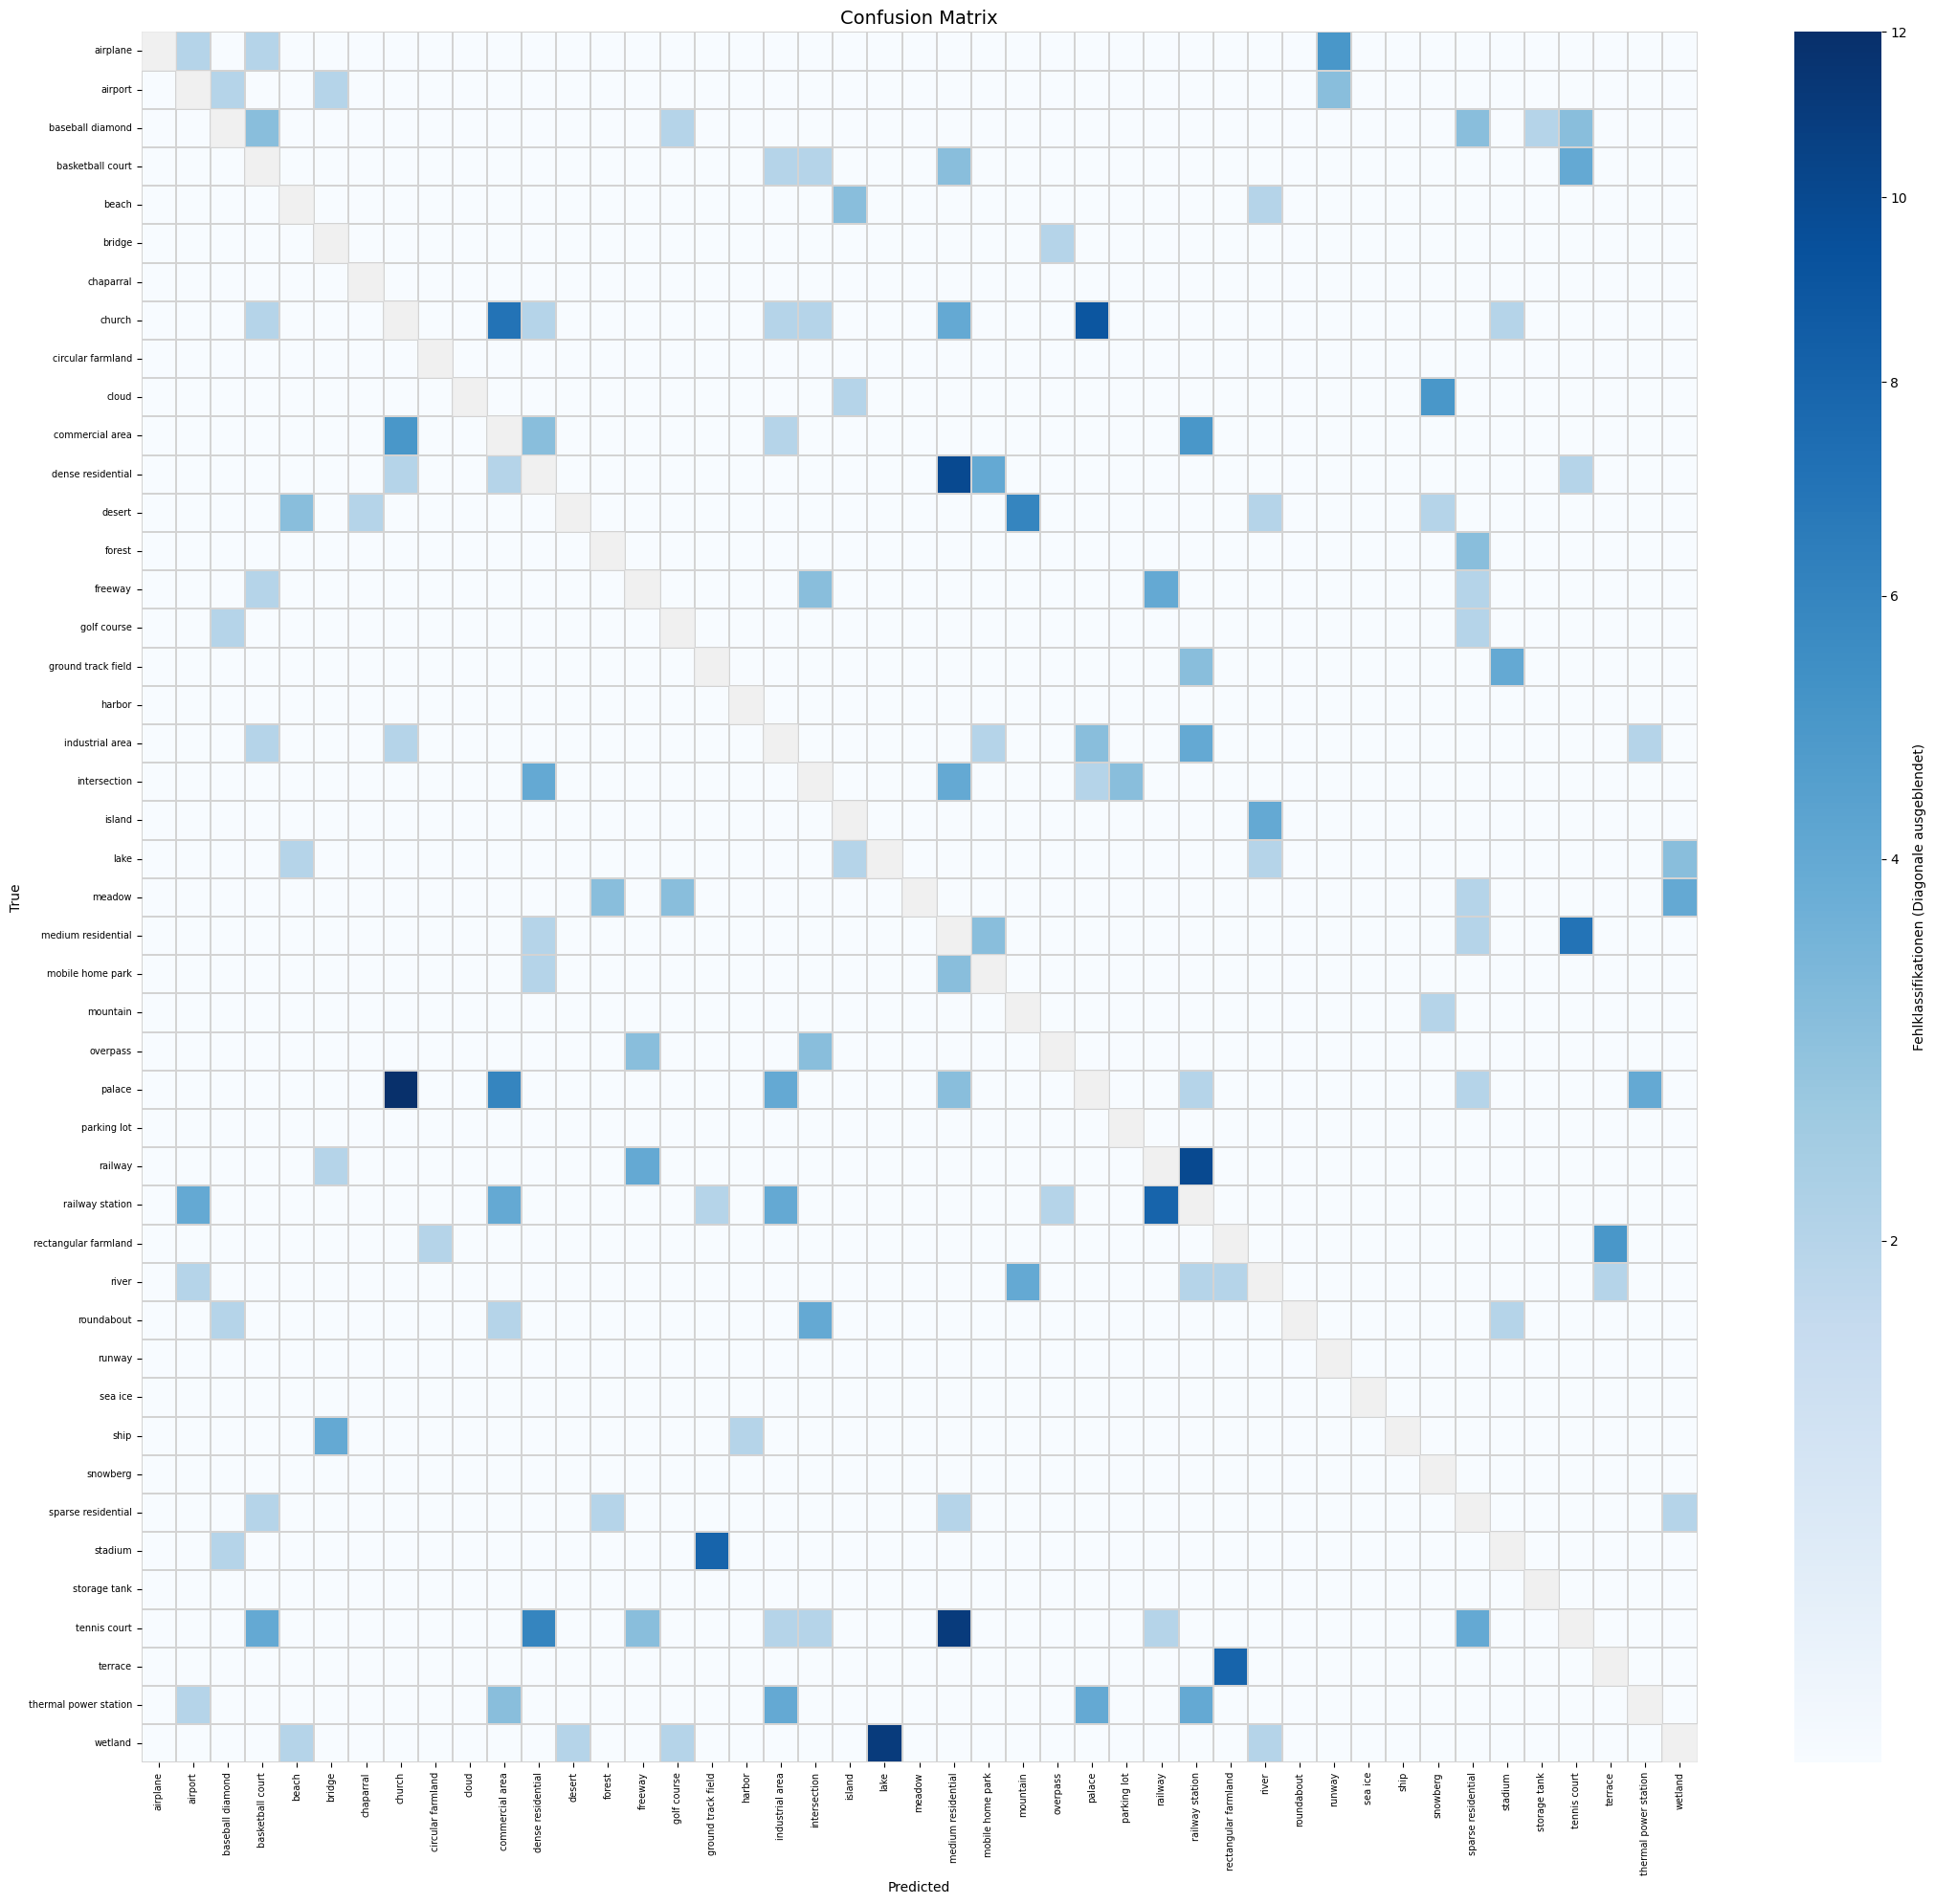

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib.colors import PowerNorm
import numpy as np

 # predictions on test set
y_pred_probs = model.predict(tf_test)
y_pred = np.argmax(y_pred_probs, axis=1)

 # accuracy per class
report = classification_report(y_test, y_pred, target_names=class_names, digits=3)
print(report)

 # heatmap
cm = confusion_matrix(y_test, y_pred)
cm_errors = cm.astype(float).copy()
np.fill_diagonal(cm_errors, np.nan)

plt.figure(figsize=(22, 20))
ax = sns.heatmap(
     cm_errors,
     annot=False,
     cmap="Blues",
     norm=PowerNorm(gamma=0.5, vmin=1, vmax=np.nanmax(cm_errors)),
     xticklabels=class_names,
     yticklabels=class_names,
     linewidths=0.3,
     linecolor="lightgrey",
     cbar_kws={"label": "Fehlklassifikationen (Diagonale ausgeblendet)"},
 )
# make diagonal less obvious
for i in range(len(class_names)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, facecolor="#f0f0f0", edgecolor="lightgrey", lw=0.3))

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()


In [20]:
%load_ext tensorboard
%reload_ext tensorboard
%tensorboard --logdir logs

Reusing TensorBoard on port 6006 (pid 5204), started 22:23:15 ago. (Use '!kill 5204' to kill it.)

#### 4. predict output 

Index: 1669
Predicted: forest
True: forest


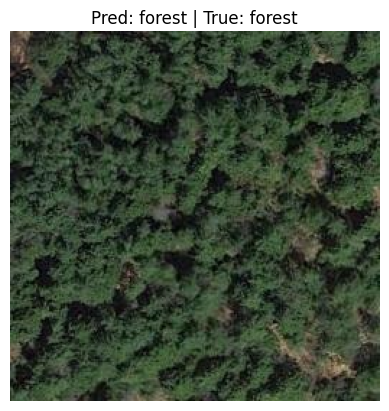

In [19]:
import random

# Zufälligen Index wählen
idx = random.randint(0, len(final_dataset["test"]) - 1)

# Sample holen
sample = final_dataset["test"][idx]

# Bild und echtes Label
img = sample["image"]
true_idx = sample["label"]

# Batch-Dimension hinzufügen
input_img = np.expand_dims(img, axis=0)

# Prediction
prediction = model.predict(input_img, verbose=0)

# Vorhersageklasse
predicted_idx = np.argmax(prediction)

# Ausgabe
print("Index:", idx)
print("Predicted:", class_names[predicted_idx])
print("True:", class_names[true_idx])

# Bild anzeigen
plt.imshow(img)
plt.title(f"Pred: {class_names[predicted_idx]} | True: {class_names[true_idx]}")
plt.axis("off")
plt.show()